# ISFS Analysis: Infraslow Fluctuation of Sigma Power — a tutorial pipeline

This notebook is a pipeline of the infraslow fluctuation of sigma power (ISFS) analysis: 
- sleep-spindle (sigma-band, ~11-16 Hz) power 
- over sleep with an infraslow (~0.01-0.1 Hz, ~10-100 s period) rhythm,
- spindles cluster preferentially at a particular phase of that rhythm.

It starts from exactly two inputs:

1. one PSG/EEG recording (EDF), and
2. one 1-second-resolution U-Sleep hypnodensity (npy) for that recording,

**Pipeline covered below:**

```
EDF + 1-s U-Sleep hypnodensity
        |
        v
3-s hypnodensity/hypnogram  ->  recording overview
        |
        v
spindle detection  ->  N2 bout detection  ->  raw EEG + spindle QC plot
        |
        v
sigma-band envelope
        |
        v
infraslow spectrum -> relative power -> baseline correction -> bi-Gaussian fit
        |                                                           |
        v                                                           v
ISFS low-pass + standardization -> phase extraction -> phase bins   ISFS peak
        |                                                           distribution
        v
spindle-vs-phase distribution  +  U-Sleep stage probability vs. phase
        |
        v
final per-subject feature summary table
```

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, ConnectionPatch
import mne
import yasa

from infraslow.processing.utils import find_stage_bouts
from infraslow.processing.spindle import spindles_detect, DEFAULT_STAGE_MAP
from infraslow.io.usleep_hypnodensity import (
    hypnodensity_to_epoch_hypnogram,
    hypnodensity_probs_at_times,
)
from infraslow.processing.infraslow import (
    eeg_envelope,
    infraslow_spectrum,
    relative_power,
    baseline_correct,
    bigaussian,
    fit_isfs,
    chromatogram_peak_area,
    isfs_lowpass,
    isfs_phase_bins,
    isfs_event_phase_distribution,
    isfs_phase_curve,
)
from infraslow.pipeline.phase import (
    bin_center_angle,
    continuous_phase_samples,
    build_subject_phase_timeseries,
    build_subject_continuous_phase_timeseries,
)
from infraslow.viz.hypnogram import plot_hypnogram

plt.rcParams["figure.dpi"] = 110
PURPLE, LPURPLE, GOLD, BLUE, GREEN = "#5b2a86", "#c9b3e6", "#f2c14e", "tab:blue", "tab:green"

## 2. User Configuration

Some of these constants (sigma/infraslow/baseline bands, N2-bout/ISFS-cycle
definitions) already exist as defaults inside `infraslow.constants`.

In [2]:
# =========================
# User Configuration
# =========================

# --- Input files (see "Expected Input Data" below for the required format) ---
# EDF file stem: loaded from $OAK/psg/Bioserenity/edf/<SUBJECT_ID>.edf via
# infraslow.io.psg_loader.BioserenityPSGLoader (Section 3)
# U-Sleep hypnodensity from $OAK/psg/Bioserenity/USleep/<SUBJECT_ID>/
# (infraslow.io.usleep_hypnodensity), so no separate hypnodensity path is set here.
SUBJECT_ID = "318562"

EDF_DIR = "$OAK/psg/Bioserenity/edf"
USLEEP_HYPNODENSITY_DIR = "$OAK/psg/Bioserenity/USleep"

# Canonical channel name (a key of infraslow.constants.BIOSERENITY_ALIAS_MAP)
# to resolve out of the EDF, and the label used in plot titles / the summary table.
CHANNEL = "C3"

# --- Sampling rates (Hz) ---
EEG_SFREQ = 200.0          # every EDF channel is resampled to this rate while loading
HYPNODENSITY_SFREQ = 1.0   # seconds per raw U-Sleep hypnodensity row (1 row = 1 second)

# --- Epoching ---
EPOCH_SEC = 3.0            # width (s) of the "hard" sleep-stage epoch BioserenityPSGLoader
                           # reduces the 1-s hypnodensity to (Section 3)

# --- Frequency bands (Hz) ---
SIGMA_BAND = (11.0, 16.0)       # spindle/sigma power-integration band
INFRASLOW_BAND = (0.01, 0.1)    # infraslow search band for the sigma-power rhythm
BASELINE_BAND = (0.06, 0.1)     # high-infraslow "noise floor" band for baseline correction
WINDOW_SEC = 100.0              # infraslow_spectrum's (length-independent) frequency-grid window

# --- N2 bout / ISFS-cycle definitions ---
MIN_N2_BOUT_SEC = 200.0          # minimum consecutive-N2 run kept as a "bout"
ISFS_PERIOD_SEC = (25.0, 100.0)  # valid ISFS cycle period range (~0.01-0.04 Hz)

# --- Phase binning ---
# N_PHASE_BINS is fixed at 8 by the reference pipeline's landmark-based phase
# scheme (`isfs_phase_bins`) -- see Section 14 for why a generic Hilbert-phase /
# arbitrary-bin-count scheme is *not* used here instead.
N_PHASE_BINS = 8

# Column order of the raw U-Sleep hypnodensity (see "Expected Input Data" below).
USLEEP_STAGE_ORDER = ("Wake", "N1", "N2", "N3", "REM")
STAGE_COLORS = {"Wake": "0.4", "N1": "#8ecae6", "N2": "#219ebc", "N3": "#023047", "REM": "#fb8500"}

## 3. Load EEG

Loaded with `infraslow.io.psg_loader.BioserenityPSGLoader`

* resolves `CHANNEL` against `BIOSERENITY_ALIAS_MAP`'s physical-channel
  aliases (montages/acquisition systems spell the same electrode differently);
* resamples every loaded channel to `EEG_SFREQ` as it is read;
* applies the loader's default 60 Hz powerline notch filter
  (`notch_freq=60.0`) after resampling.

`annotation_loader` is set explicitly to
`make_usleep_annotation_loader(CHANNEL, epoch_sec=EPOCH_SEC, src_epoch_sec=HYPNODENSITY_SFREQ)`

In [3]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)

from infraslow.io.psg_loader import BioserenityPSGLoader
from infraslow.io.usleep_hypnodensity import make_usleep_annotation_loader

# load PSG and usleep_annotation
psg_loader = BioserenityPSGLoader(
    subject_id=SUBJECT_ID,
    edf_dir=EDF_DIR,
    sf=EEG_SFREQ,
    requested_channels=[CHANNEL],
    annotation_loader=make_usleep_annotation_loader(
        CHANNEL, 
        base_dir=USLEEP_HYPNODENSITY_DIR,
        epoch_sec=EPOCH_SEC, src_epoch_sec=HYPNODENSITY_SFREQ,
        stage_order=USLEEP_STAGE_ORDER,
    ),
).load()

print(f"\nEDF path:            {psg_loader.edf_path}")
print(f"Resolved channel(s): {psg_loader.resolved_channels}")
if psg_loader.missing_channels:
    print(f"WARNING -- missing channel(s): {psg_loader.missing_channels}")
if psg_loader.conflicts:
    print(f"WARNING -- channel conflict(s): {psg_loader.conflicts}")
assert CHANNEL in psg_loader.resolved_channels, (
    f"'{CHANNEL}' was not resolved from {SUBJECT_ID}'s EDF -- "
    f"missing: {psg_loader.missing_channels}"
)

eeg = np.asarray(psg_loader.get_channel(CHANNEL), dtype=float)
sf = float(psg_loader.sf)
eeg_duration_sec = len(eeg) / sf

t_epoch = psg_loader.annotations["t"].to_numpy()
hypnodensity_3s = psg_loader.annotations[list(USLEEP_STAGE_ORDER)].to_numpy()
hypnogram_3s = psg_loader.annotations["stage"].to_numpy()
n_epochs_3s = len(hypnogram_3s)

print(f"\nEEG ({CHANNEL}): {len(eeg)} samples @ {sf:g} Hz "
      f"= {eeg_duration_sec/60:.1f} min ({eeg_duration_sec/3600:.2f} h)")
print(f"psg_loader.annotations: {n_epochs_3s} epochs of {EPOCH_SEC:g} s "
      f"({n_epochs_3s * EPOCH_SEC / 3600:.2f} h; columns: {list(psg_loader.annotations.columns)})")

14:51:00 [INFO] Loading subject 318562 from /oak/stanford/groups/mignot/psg/Bioserenity/edf/318562.edf


initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f4009ac4b70> 



___________________________________________________________________
Processing: 318562 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/318562.edf
 duration 07.40.46, 27646s | time 21.51.51 - 05.32.37 | date 01.01.12

 signals: 29 (of 29) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | PPG | Snore | imp | rr | Leak | EPAP
  IPAP | Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+
14:51:01 [INFO] EDF exposes 28 physical channels.
14:51:01 [INFO] Applying 60 Hz notch filter (FIR) at 200 Hz sampling rate.
14:51:01 [INFO] Loaded 1 channel(s), 5529200 sample(s); 0 missing, 0 conflict record(s).



EDF path:            /oak/stanford/groups/mignot/psg/Bioserenity/edf/318562.edf
Resolved channel(s): {'C3': 'C3'}

EEG (C3): 5529200 samples @ 200 Hz = 460.8 min (7.68 h)
psg_loader.annotations: 9210 epochs of 3 s (7.67 h; columns: ['t', 'Wake', 'N1', 'N2', 'N3', 'REM', 'stage'])


## 4. Recording Overview

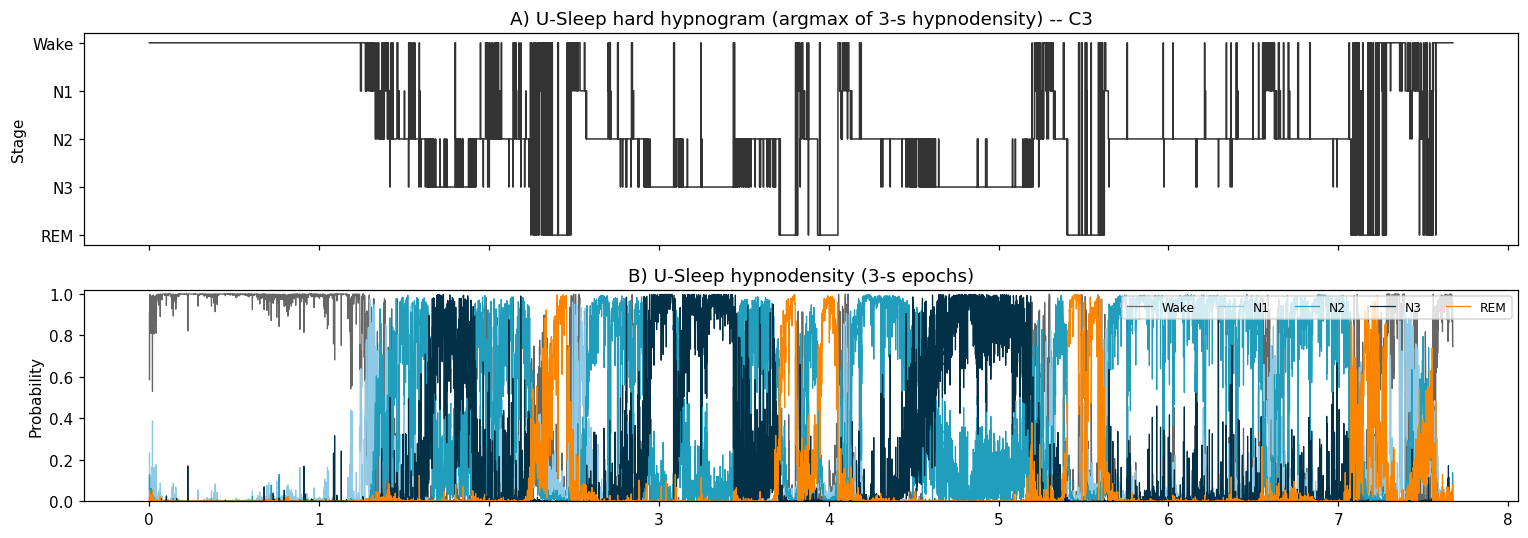

In [4]:
STAGE_TO_INT = {"Wake": 0, "N1": 1, "N2": 2, "N3": 3, "REM": 4}
hyp_int_3s = np.array([STAGE_TO_INT[s] for s in hypnogram_3s])
t_hr = t_epoch / 3600.0

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True,
                          gridspec_kw=dict(height_ratios=[1, 1]))

# A) Hard hypnogram (argmax of the 3-s hypnodensity)
axes[0].step(t_hr, hyp_int_3s, where="post", color="0.2", lw=1.0)
axes[0].set_yticks(list(STAGE_TO_INT.values()))
axes[0].set_yticklabels(list(STAGE_TO_INT.keys()))
axes[0].invert_yaxis()
axes[0].set_ylabel("Stage")
axes[0].set_title(f"A) U-Sleep hard hypnogram (argmax of 3-s hypnodensity) -- {CHANNEL}")

# B) Hypnodensity (soft stage probabilities)
for stage in USLEEP_STAGE_ORDER:
    i = USLEEP_STAGE_ORDER.index(stage)
    axes[1].plot(t_hr, hypnodensity_3s[:, i], lw=0.8, color=STAGE_COLORS[stage], label=stage)
axes[1].set(ylabel="Probability", ylim=(0, 1.02))
axes[1].legend(loc="upper right", ncol=5, fontsize=8, frameon=True)
axes[1].set_title("B) U-Sleep hypnodensity (3-s epochs)")

fig.tight_layout()

## 5. Detect Spindles

`spindles_detect` (`infraslow.processing.spindle`) is an adapter over
`yasa.spindles_detect`: 
- requested stage(s) (`include=(2,)` = N2 only.

In [5]:
spindles = spindles_detect(psg_loader, ch_names=CHANNEL, include=(2,), epoch_sec=EPOCH_SEC)
assert spindles is not None, "No spindles detected -- check CHANNEL/SUBJECT_ID and data quality"
spindle_summary = spindles.summary()
spindle_summary.head()

14:51:02 [WARNING] Hypnogram is SHORTER than data by 16.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (3.305 s)

Setting up band-pass filter from 12 - 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 12.00
- Lower transition bandwidth: 1.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 1.50 Hz (-6 dB cutoff frequency: 15.75 Hz)
- F

,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,4922.835,4923.470,4923.710,0.875,49.909417,34.397901,12.761296,2.210826,0.318355,13.036502,12.0,0.721591,2,C3,0
1,5193.960,5194.480,5194.730,0.770,49.079066,38.024562,11.260412,2.014194,0.405499,12.486636,9.0,0.670968,2,C3,0
2,5296.925,5297.235,5297.695,0.770,57.527885,41.314724,12.893674,2.221245,0.452105,12.339883,9.0,0.400000,2,C3,0
3,5311.085,5311.865,5312.030,0.945,63.546079,31.319683,12.085872,2.033154,0.290347,12.548896,12.0,0.821053,2,C3,0
4,5316.125,5316.175,5316.785,0.660,49.621512,38.525364,12.757026,2.222823,0.312426,12.327034,8.0,0.075188,2,C3,0


In [6]:
n_spindles = len(spindle_summary)
n2_total_sec = float(np.sum(hypnogram_3s == "N2") * EPOCH_SEC)
spindle_rate_per_min = n_spindles / (n2_total_sec / 60.0) if n2_total_sec > 0 else np.nan

mean_spindle_duration_sec = spindle_summary["Duration"].mean()
mean_spindle_amplitude_uv = spindle_summary["Amplitude"].mean()
mean_spindle_frequency_hz = spindle_summary["Frequency"].mean()
mean_spindle_power = spindle_summary["AbsPower"].mean()  # median absolute power, log10 uV^2/Hz

print(f"Spindles detected:        {n_spindles}")
print(f"Spindle rate:              {spindle_rate_per_min:.2f} /min of N2 sleep "
      f"({n2_total_sec/60:.1f} min of N2)")
print(f"Mean duration:             {mean_spindle_duration_sec:.2f} s")
print(f"Mean amplitude:            {mean_spindle_amplitude_uv:.1f} uV (peak-to-peak)")
print(f"Mean frequency:            {mean_spindle_frequency_hz:.2f} Hz")
print(f"Mean power (AbsPower):     {mean_spindle_power:.2f} log10 uV^2")

Spindles detected:        239
Spindle rate:              1.29 /min of N2 sleep (185.8 min of N2)
Mean duration:             0.74 s
Mean amplitude:            51.7 uV (peak-to-peak)
Mean frequency:            12.87 Hz
Mean power (AbsPower):     2.00 log10 uV^2


### Spindle-Locked Average Waveform

Grand-average raw EEG waveform, time-locked to each detected spindle's own
`Peak` and pooled across every spindle in `spindle_summary` (all N2 spindles
on `CHANNEL`, whole recording)

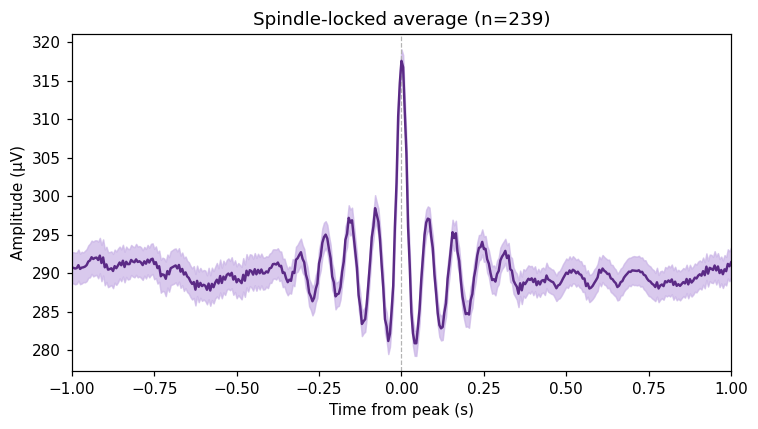

In [7]:
if n_spindles:
    TL_BEFORE, TL_AFTER = 1.0, 1.0  # seconds before/after each spindle's Peak

    # (n_spindles, n_times) raw EEG, one row per spindle, centered on its own Peak
    sync_raw = spindles.get_sync_events(center="Peak", time_before=TL_BEFORE, time_after=TL_AFTER,
                                         as_dataframe=False)[0]
    bef, aft = int(sf * TL_BEFORE), int(sf * TL_AFTER)
    tl_time = np.arange(-bef, aft + 1) / sf

    mean_raw = sync_raw.mean(axis=0)
    ci_raw = 1.96 * sync_raw.std(axis=0, ddof=1) / np.sqrt(n_spindles)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.axvline(0, color="0.7", lw=0.8, ls="--")
    ax.fill_between(tl_time, mean_raw - ci_raw, mean_raw + ci_raw, color=LPURPLE, alpha=0.7)
    ax.plot(tl_time, mean_raw, color=PURPLE, lw=1.6)
    ax.set(xlim=(tl_time[0], tl_time[-1]), xlabel="Time from peak (s)", ylabel="Amplitude (µV)",
           title=f"Spindle-locked average (n={n_spindles})")
    fig.tight_layout()
else:
    print("No spindles detected -- skipping spindle-locked average plot.")

## 6. N2 Bout Detection and Summary

An **N2 bout** is a maximal run of *consecutive* 3-s N2 epochs at least
`MIN_N2_BOUT_SEC` (200 s) long

In [8]:
n2_mask = hypnogram_3s == "N2"
hypnogram_int_3s = np.array([DEFAULT_STAGE_MAP[s.lower()] for s in hypnogram_3s])

n2_bouts = np.asarray(
    find_stage_bouts(hypnogram_int_3s, stage_codes=(2,), epoch_sec=EPOCH_SEC, min_dur=MIN_N2_BOUT_SEC)
).reshape(-1, 2)

if n2_bouts.size == 0:
    print("WARNING: no N2 bouts >= MIN_N2_BOUT_SEC found -- all downstream N2/ISFS "
          "analysis below will be skipped for this subject/channel.")

bout_durations_sec = n2_bouts[:, 1] - n2_bouts[:, 0] if n2_bouts.size else np.array([])
n2_bout_total_sec = float(bout_durations_sec.sum())


def _times_in_any_bout(times, bouts):
    times = np.asarray(times, dtype=float)
    if bouts.size == 0 or times.size == 0:
        return np.zeros(times.shape, dtype=bool)
    starts, stops = bouts[:, 0], bouts[:, 1]
    idx = np.clip(np.searchsorted(starts, times, side="right") - 1, 0, len(starts) - 1)
    return (times >= starts[idx]) & (times < stops[idx])


peak_times = spindle_summary["Peak"].to_numpy()
n_spindles_in_n2_bouts = int(_times_in_any_bout(peak_times, n2_bouts).sum())
n2_bout_spindle_rate = (
    n_spindles_in_n2_bouts / (n2_bout_total_sec / 60.0) if n2_bout_total_sec > 0 else np.nan
)


def _bout_has_spindle(a, b, times=peak_times):
    return bool(np.any((times >= a) & (times < b)))


# The subset of N2 bouts containing >= 1 spindle -- used below (Section 7) to pick
# a representative window, and again in Section 9 for the spectral analysis.
n2_bouts_with_spindles = np.array([b for b in n2_bouts if _bout_has_spindle(*b)]).reshape(-1, 2)
HAS_SPINDLE_BOUTS = len(n2_bouts_with_spindles) > 0

print(f"Number of N2 bouts:          {len(n2_bouts)}")
print(f"Total N2 (bout) duration:    {n2_bout_total_sec/60:.1f} min")
if bout_durations_sec.size:
    print(f"Mean bout duration:          {bout_durations_sec.mean():.1f} s")
    print(f"Median bout duration:        {np.median(bout_durations_sec):.1f} s")
    print(f"Min/max bout duration:       {bout_durations_sec.min():.1f} / {bout_durations_sec.max():.1f} s")
print(f"Spindles within N2 bouts:    {n_spindles_in_n2_bouts}/{n_spindles}")
print(f"N2-bout spindle rate:        {n2_bout_spindle_rate:.2f} /min")
print(f"N2 bouts containing >= 1 spindle: {len(n2_bouts_with_spindles)}/{len(n2_bouts)}")

Number of N2 bouts:          11
Total N2 (bout) duration:    71.5 min
Mean bout duration:          390.3 s
Median bout duration:        381.0 s
Min/max bout duration:       237.0 / 759.0 s
Spindles within N2 bouts:    120/239
N2-bout spindle rate:        1.68 /min
N2 bouts containing >= 1 spindle: 11/11


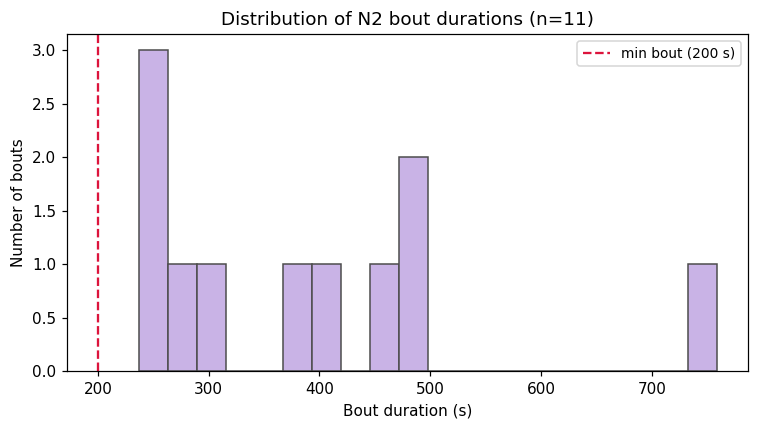

In [9]:
if bout_durations_sec.size:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(bout_durations_sec, bins=20, color=LPURPLE, edgecolor="0.3")
    ax.axvline(MIN_N2_BOUT_SEC, color="crimson", ls="--", lw=1.5, label=f"min bout ({MIN_N2_BOUT_SEC:g} s)")
    ax.set(xlabel="Bout duration (s)", ylabel="Number of bouts",
           title=f"Distribution of N2 bout durations (n={len(bout_durations_sec)})")
    ax.legend(fontsize=9)
    fig.tight_layout()
else:
    print("No N2 bouts to plot.")

## 7. Raw EEG and Spindle Visualization

A quality-control figure: the hypnogram with N2 bouts highlighted (top), and a
representative window of raw EEG with detected spindles shaded (bottom)

In [10]:
WINDOW_SEC = 200.0  # length (s) of the representative window shown below

_window_source = n2_bouts_with_spindles if HAS_SPINDLE_BOUTS else n2_bouts
if _window_source.size:
    BOUT_IDX = 0
    bout0 = _window_source[BOUT_IDX]
    bout_peaks = peak_times[(peak_times >= bout0[0]) & (peak_times < bout0[1])]
    if bout_peaks.size:
        win_start = max(bout0[0], bout_peaks[0] - WINDOW_SEC / 2)
        win_end = min(bout0[1], win_start + WINDOW_SEC)
        win_start = max(bout0[0], win_end - WINDOW_SEC)
    else:
        win_start = bout0[0]
        win_end = min(bout0[0] + WINDOW_SEC, bout0[1])
else:
    BOUT_IDX = None
    win_start, win_end = 0.0, min(WINDOW_SEC, eeg_duration_sec)

print(f"Representative window: {win_start:.0f}-{win_end:.0f} s "
      f"({'bout #' + str(BOUT_IDX) if BOUT_IDX is not None else 'no N2 bout available'})")

Representative window: 9267-9467 s (bout #0)


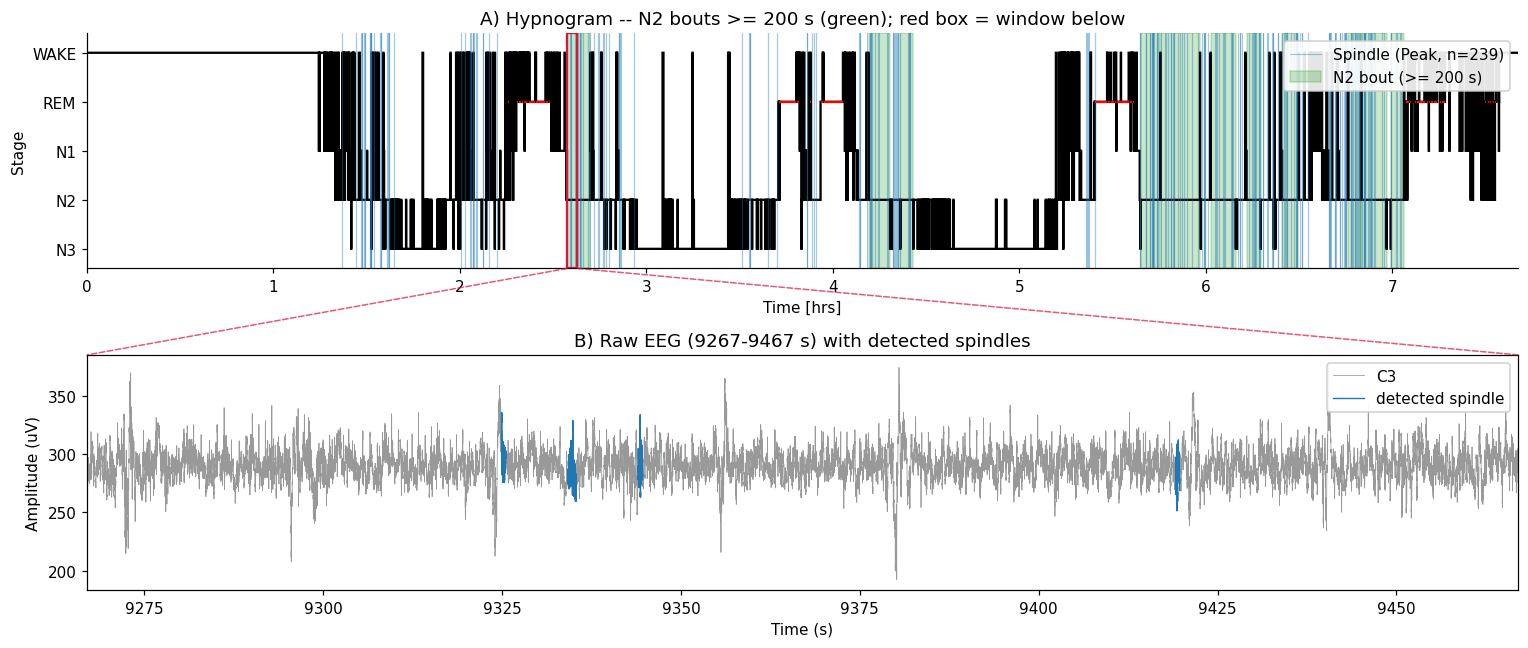

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# --- Top: hypnogram with N2 bouts shaded, spindles marked, window boxed ---
plot_hypnogram(psg_loader, spindles=spindles, ax=axes[0], mark_color=BLUE, epoch_sec=EPOCH_SEC)
for k, (a, b) in enumerate(n2_bouts):
    axes[0].axvspan(a / 3600, b / 3600, color=GREEN, alpha=0.25, zorder=0,
                     label=f"N2 bout (>= {MIN_N2_BOUT_SEC:g} s)" if k == 0 else None)
axes[0].axvspan(win_start / 3600, win_end / 3600, facecolor="none", edgecolor="crimson", lw=1.5, zorder=6)
axes[0].set_title(f"A) Hypnogram -- N2 bouts >= {MIN_N2_BOUT_SEC:g} s (green); red box = window below")
axes[0].legend(loc="upper right", frameon=True, framealpha=0.9)

# --- Bottom: raw EEG over the window, detected spindles shaded blue ---
t = np.arange(len(eeg)) / sf
m = (t >= win_start) & (t <= win_end)
axes[1].plot(t[m], eeg[m], color="0.6", lw=0.5, label=CHANNEL)
starts = spindle_summary["Start"].to_numpy()
ends = spindle_summary["End"].to_numpy()
in_win = (starts < win_end) & (ends > win_start)
for i, (s0, e0) in enumerate(zip(starts[in_win], ends[in_win])):
    seg = (t >= s0) & (t <= e0)
    axes[1].plot(t[seg], eeg[seg], color=BLUE, lw=0.9, label="detected spindle" if i == 0 else None)
axes[1].set(xlim=(win_start, win_end), xlabel="Time (s)", ylabel="Amplitude (uV)",
            title=f"B) Raw EEG ({win_start:.0f}-{win_end:.0f} s) with detected spindles")
axes[1].legend(loc="upper right", frameon=True, framealpha=0.9)

y_hyp = axes[0].get_ylim()[0]
y_eeg = axes[1].get_ylim()[1]
for x in (win_start, win_end):
    fig.add_artist(ConnectionPatch(
        xyA=(x / 3600, y_hyp), coordsA=axes[0].transData,
        xyB=(x, y_eeg), coordsB=axes[1].transData,
        color="crimson", lw=1.0, ls="--", alpha=0.7))

fig.tight_layout()

## 8. Sigma Envelope

```
Raw EEG
   |
   v
Sigma-band filtering (11-16 Hz)
   |
   v
Sigma power (Morlet wavelet analytic amplitude, squared)
   |
   v
Sigma envelope (down-sampled to 1 Hz, dB)
```

`eeg_envelope` (`infraslow.processing.infraslow`) computes this whole chain:
by default (`wavelet=True`) it runs a Morlet wavelet transform across a grid
of frequencies spanning `SIGMA_BAND`, averages the magnitude across frequency,
squares it (`kind="power"`), bins the result into 1-s (`sf_env=1.0`) windows,
and converts to dB. This *is* the sigma-power course every later section
builds on.

In [12]:
t_env, sigma_db = eeg_envelope(eeg, sf, band=SIGMA_BAND, sf_env=1.0, to_db=True, kind="power", wavelet=True)

def env_at(times, t=t_env, y=sigma_db):
    # Interpolate the sigma envelope at arbitrary times (e.g. spindle peaks).
    return np.interp(times, t, y)

print(f"Sigma envelope: {len(t_env)} samples @ 1 Hz ({t_env[-1]/60:.1f} min)")

Sigma envelope: 27646 samples @ 1 Hz (460.8 min)


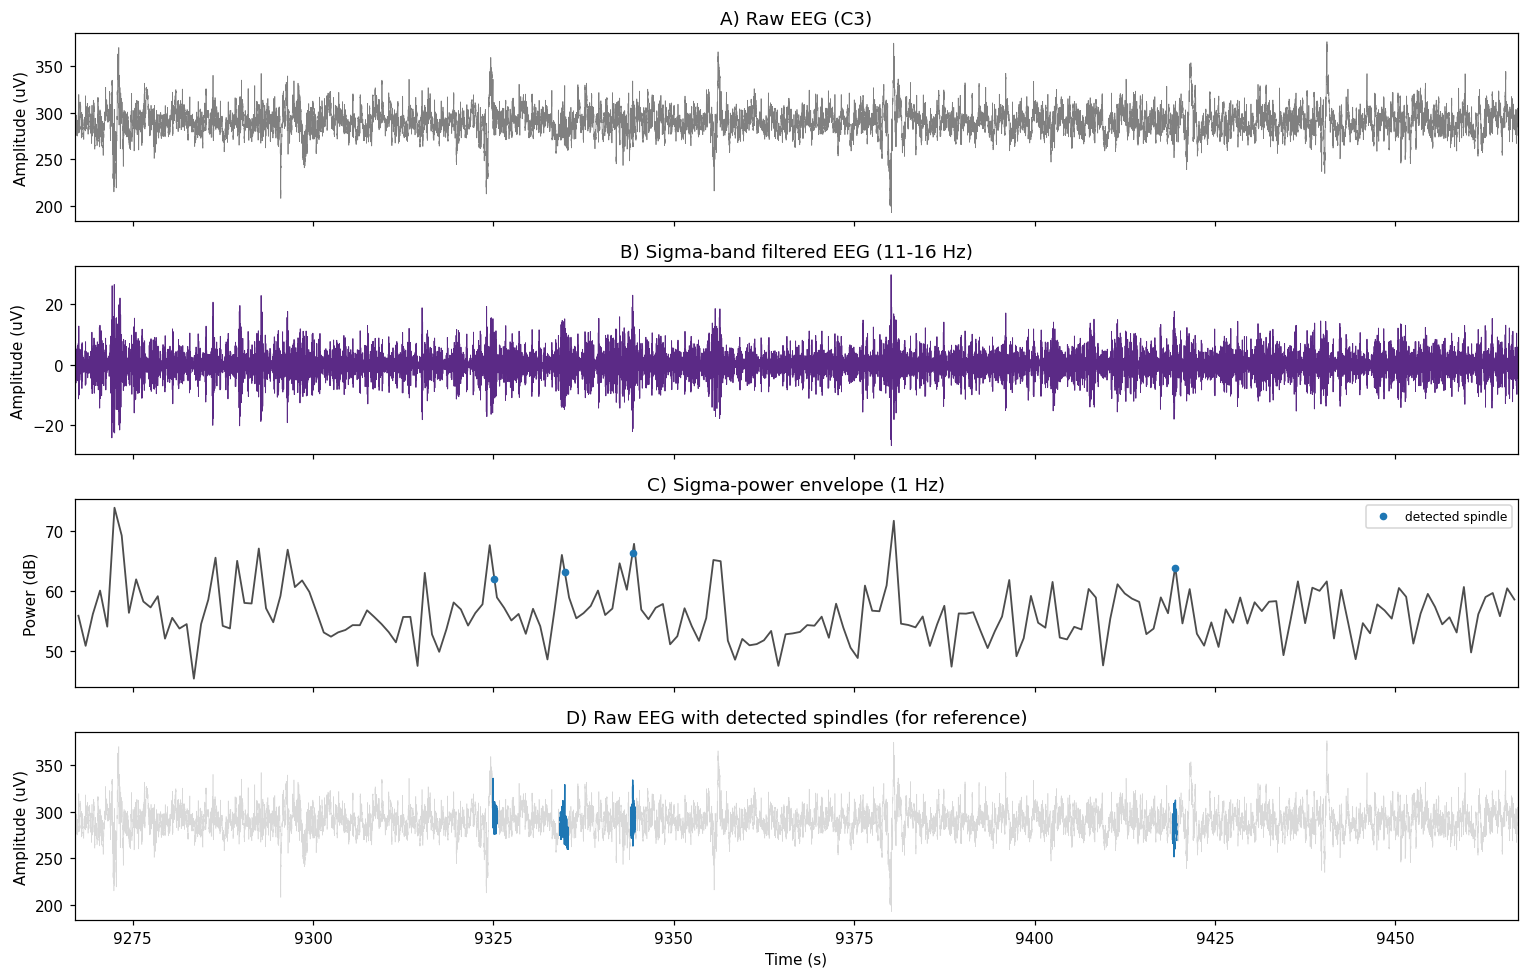

In [13]:
sigma_filtered = mne.filter.filter_data(eeg, sf, l_freq=SIGMA_BAND[0], h_freq=SIGMA_BAND[1],
                                         method="fir", verbose=False)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
m = (t >= win_start) & (t <= win_end)
me = (t_env >= win_start) & (t_env <= win_end)
pk = peak_times[(peak_times >= win_start) & (peak_times <= win_end)]

axes[0].plot(t[m], eeg[m], color="0.5", lw=0.5)
axes[0].set(ylabel="Amplitude (uV)", title=f"A) Raw EEG ({CHANNEL})")

axes[1].plot(t[m], sigma_filtered[m], color=PURPLE, lw=0.6)
axes[1].set(ylabel="Amplitude (uV)",
            title=f"B) Sigma-band filtered EEG ({SIGMA_BAND[0]:g}-{SIGMA_BAND[1]:g} Hz)")

axes[2].plot(t_env[me], sigma_db[me], color="0.3", lw=1.2)
axes[2].plot(pk, env_at(pk), "o", color=BLUE, ms=4, label="detected spindle")
axes[2].set(ylabel="Power (dB)", title="C) Sigma-power envelope (1 Hz)")
axes[2].legend(loc="upper right", fontsize=8)

axes[3].plot(t[m], eeg[m], color="0.85", lw=0.4)
starts_w = spindle_summary["Start"].to_numpy()
ends_w = spindle_summary["End"].to_numpy()
in_w = (starts_w < win_end) & (ends_w > win_start)
for s0, e0 in zip(starts_w[in_w], ends_w[in_w]):
    seg = (t >= s0) & (t <= e0)
    axes[3].plot(t[seg], eeg[seg], color=BLUE, lw=0.9)
axes[3].set(xlabel="Time (s)", ylabel="Amplitude (uV)", xlim=(win_start, win_end),
            title="D) Raw EEG with detected spindles (for reference)")

fig.tight_layout()

## 9. Relative Sigma-Envelope Spectrum

The infraslow spectrum is computed **per N2 bout that contains at least one
detected spindle** (spindle-free bouts are dropped), then averaged. 
`infraslow_spectrum` uses a Morlet wavelet transform (not Welch/multitaper) evaluated 
on a fixed frequency grid independent of each bout's length, so spectra from
different-length bouts can be stacked and averaged directly.

In [14]:
# n2_bouts_with_spindles / HAS_SPINDLE_BOUTS were already computed in Section 6.
print(f"{len(n2_bouts_with_spindles)}/{len(n2_bouts)} N2 bout(s) contain >= 1 spindle")

freqs = None
psd_list = []
for a, b in n2_bouts_with_spindles:
    m0 = (t_env >= a) & (t_env < b)
    spec = infraslow_spectrum(sigma_db[m0], sf_env=1.0, window_sec=WINDOW_SEC)
    freqs = spec.freqs
    psd_list.append(spec.psd)

if HAS_SPINDLE_BOUTS:
    psd_all = np.vstack(psd_list)
    mean_psd = psd_all.mean(axis=0)
    band_m = (freqs >= INFRASLOW_BAND[0]) & (freqs <= INFRASLOW_BAND[1])
    assert band_m.any(), "INFRASLOW_BAND does not overlap the computed frequency grid"

    rel = relative_power(mean_psd, freqs, INFRASLOW_BAND)
    rel_all = relative_power(psd_all, freqs, INFRASLOW_BAND)
    rel_sd = rel_all.std(axis=0, ddof=1) if rel_all.shape[0] > 1 else np.zeros_like(rel)

    real_peak_idx = int(np.argmax(rel[band_m]))
    real_peak_freq = float(freqs[band_m][real_peak_idx])
    print(f"Empirical (pre-fit) peak: {real_peak_freq:.4f} Hz (~{1/real_peak_freq:.0f} s)")
else:
    print("No spindle-containing N2 bouts -- skipping the spectral/bi-Gaussian analysis "
          "(Sections 9-12) for this subject/channel.")

11/11 N2 bout(s) contain >= 1 spindle
Empirical (pre-fit) peak: 0.0438 Hz (~23 s)


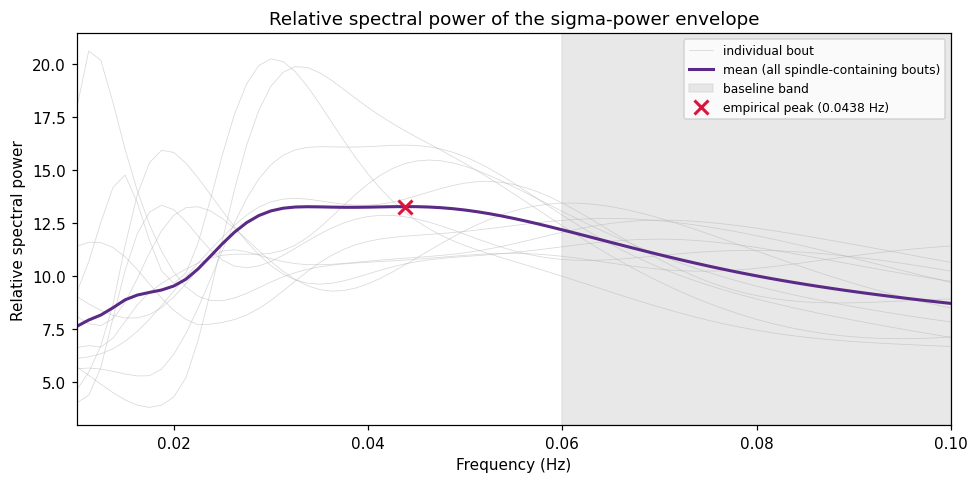

In [15]:
if HAS_SPINDLE_BOUTS:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for i in range(rel_all.shape[0]):
        ax.plot(freqs[band_m], rel_all[i, band_m], color="0.7", lw=0.5, alpha=0.5,
                label="individual bout" if i == 0 else None)
    ax.plot(freqs[band_m], rel[band_m], color=PURPLE, lw=2, label="mean (all spindle-containing bouts)")
    ax.axvspan(*BASELINE_BAND, color="0.85", alpha=0.6, zorder=0, label="baseline band")
#     ax.axvline(0.02, color="crimson", ls="--", lw=1, label="~0.02 Hz (~50 s)")
    ax.plot([real_peak_freq], [rel[band_m][real_peak_idx]], "x", color="crimson", ms=9, mew=2,
            label=f"empirical peak ({real_peak_freq:.4f} Hz)")
    ax.set(xlim=INFRASLOW_BAND, xlabel="Frequency (Hz)", ylabel="Relative spectral power",
           title="Relative spectral power of the sigma-power envelope")
    ax.legend(fontsize=8)
    fig.tight_layout()

## 10. Baseline Correction

`baseline_correct` subtracts the mean relative power over `BASELINE_BAND`
(0.06-0.1 Hz, high-infraslow frequencies with no expected ISFS peak) from the
whole spectrum -- treating that band's level as the noise floor the true ISFS
peak should sit above.

In [16]:
if HAS_SPINDLE_BOUTS:
    corrected = baseline_correct(rel, freqs, BASELINE_BAND)
    baseline_level = float(rel[(freqs >= BASELINE_BAND[0]) & (freqs <= BASELINE_BAND[1])].mean())
    print(f"Baseline level ({BASELINE_BAND[0]:g}-{BASELINE_BAND[1]:g} Hz mean): {baseline_level:.4g}")

Baseline level (0.06-0.1 Hz mean): 10.18


## 11. Bi-Gaussian ISFS Fit

A **bi-Gaussian** -- two Gaussian halves sharing one peak `mu` but independent
left/right standard deviations `sd_l`/`sd_r` -- captures the asymmetric shape
(steep rise, slow decay) real infraslow spectra show:

```
amp * exp(-0.5 * ((f - mu) / sd) ** 2),   sd = sd_l if f < mu else sd_r
```

In [17]:
FIT_OK = False
if HAS_SPINDLE_BOUTS:
    try:
        fit = fit_isfs(freqs, corrected, infraslow_band=INFRASLOW_BAND, baseline_band=BASELINE_BAND)
        FIT_OK = True
    except (RuntimeError, ValueError) as exc:
        fit = None
        print(f"Bi-Gaussian fit failed ({exc}); skipping fit-dependent plots/features.")

if FIT_OK:
    amp, mu, sd_l, sd_r = fit["popt"]
    lo, hi, bandwidth = fit["lo"], fit["hi"], fit["bandwidth"]
    auc, threshold, detected = fit["auc"], fit["threshold"], fit["detected"]
    isfs_peak_freq = mu
    isfs_peak_period_sec = 1.0 / mu

    fg = np.linspace(*INFRASLOW_BAND, 400)
    chrom = chromatogram_peak_area(fg, bigaussian(fg, *fit["popt"]), threshold=threshold,
                                    infraslow_band=INFRASLOW_BAND)
    isfs_chromatogram_area = chrom["area"]

    print(f"ISFS detected:   {detected}")
    print(f"Peak frequency:  {mu:.4f} Hz (~{isfs_peak_period_sec:.0f} s period)")
    print(f"Peak amplitude:  {amp:.4g}")
    print(f"Left/right SD:   {sd_l:.4f} / {sd_r:.4f} Hz")
    print(f"Bandwidth:       {bandwidth:.4f} Hz ({lo:.4f}-{hi:.4f} Hz)")
    print(f"AUC:             {auc:.4g}")
    print(f"Chromatogram peak area: {isfs_chromatogram_area:.4g}")
else:
    isfs_peak_freq = isfs_peak_period_sec = amp = bandwidth = auc = isfs_chromatogram_area = np.nan
    detected = False

ISFS detected:   True
Peak frequency:  0.0438 Hz (~23 s period)
Peak amplitude:  3.491
Left/right SD:   0.0117 / 0.0141 Hz
Bandwidth:       0.0257 Hz (0.0321-0.0578 Hz)
AUC:             0.07692
Chromatogram peak area: 0.05821


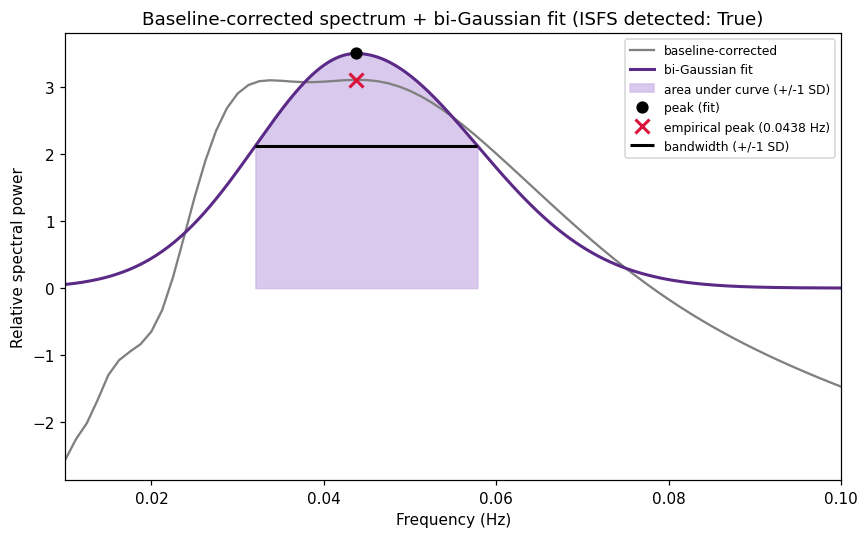

In [18]:
if FIT_OK:
    f_auc = np.linspace(lo, hi, 400)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(freqs[band_m], corrected[band_m], color="0.5", lw=1.5, label="baseline-corrected")
    ax.plot(fg, bigaussian(fg, *fit["popt"]), color=PURPLE, lw=2, label="bi-Gaussian fit")
    # ax.axhline(threshold, ls=":", color="0.3", label="threshold (1.5x baseline SD)")
    ax.fill_between(f_auc, bigaussian(f_auc, *fit["popt"]), color=LPURPLE, alpha=0.7,
                     label="area under curve (+/-1 SD)")
    ax.plot([mu], [bigaussian(mu, *fit["popt"])], "o", color="k", ms=7, zorder=5, label="peak (fit)")
    if HAS_SPINDLE_BOUTS:
        ax.plot([real_peak_freq], [corrected[band_m][real_peak_idx]], "x", color="crimson", ms=9,
                mew=2, zorder=6, label=f"empirical peak ({real_peak_freq:.4f} Hz)")
    ax.hlines(bigaussian(lo, *fit["popt"]), lo, hi, color="k", lw=2, label="bandwidth (+/-1 SD)")
    ax.set(xlim=INFRASLOW_BAND, xlabel="Frequency (Hz)", ylabel="Relative spectral power",
           title=f"Baseline-corrected spectrum + bi-Gaussian fit (ISFS detected: {detected})")
    ax.legend(fontsize=8)
    fig.tight_layout()

## 12. ISFS Peak Distribution

Peak frequency across bouts: mean=0.0409 Hz, median=0.0438 Hz, SD=0.0202 Hz, IQR=0.0325 Hz, n=11
(For reference: 0.02 Hz corresponds to a ~50 s period -- peaks are not forced to this value.)


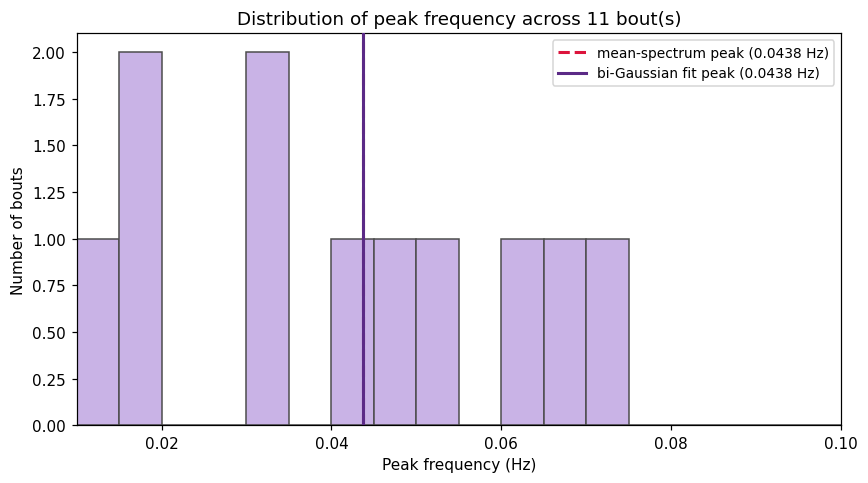

In [19]:
if HAS_SPINDLE_BOUTS and rel_all.shape[0] >= 2:
    bout_peak_freqs = freqs[band_m][np.argmax(rel_all[:, band_m], axis=1)]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bin_w = 0.005
    bins = np.arange(INFRASLOW_BAND[0], INFRASLOW_BAND[1] + bin_w, bin_w)
    ax.hist(bout_peak_freqs, bins=bins, color=LPURPLE, edgecolor="0.3", zorder=2)
    ax.axvline(real_peak_freq, color="crimson", lw=2, ls="--", zorder=4,
               label=f"mean-spectrum peak ({real_peak_freq:.4f} Hz)")
    if FIT_OK:
        ax.axvline(mu, color=PURPLE, lw=2, ls="-", zorder=4, label=f"bi-Gaussian fit peak ({mu:.4f} Hz)")
    ax.set(xlim=INFRASLOW_BAND, xlabel="Peak frequency (Hz)", ylabel="Number of bouts",
           title=f"Distribution of peak frequency across {len(bout_peak_freqs)} bout(s)")
    ax.legend(fontsize=9)
    fig.tight_layout()

    print(f"Peak frequency across bouts: mean={bout_peak_freqs.mean():.4f} Hz, "
          f"median={np.median(bout_peak_freqs):.4f} Hz, SD={bout_peak_freqs.std(ddof=1):.4f} Hz, "
          f"IQR={np.subtract(*np.percentile(bout_peak_freqs, [75, 25])):.4f} Hz, "
          f"n={len(bout_peak_freqs)}")
    print("(For reference: 0.02 Hz corresponds to a ~50 s period -- peaks are not forced to this value.)")
else:
    print("Fewer than 2 spindle-containing N2 bouts -- skipping the peak-distribution plot.")

## 13. ISFS Filtering and Standardization

```
Sigma envelope
        |
        v
ISFS low-pass filtering (isfs_lowpass: Tukey-tapered, 5th-order
Butterworth, -3 dB at 0.04 Hz, zero-phase filtfilt)
        |
        v
Infraslow sigma-power oscillation (whole-night)
```

In [20]:
HAS_N2_BOUTS = n2_bouts.size > 0
if HAS_N2_BOUTS:
    isfs_filtered = isfs_lowpass(sigma_db, sf_env=1.0)  # whole-night, once
else:
    isfs_filtered = np.array([])
    print("No N2 bouts -- skipping ISFS filtering/phase analysis (Sections 13-17).")

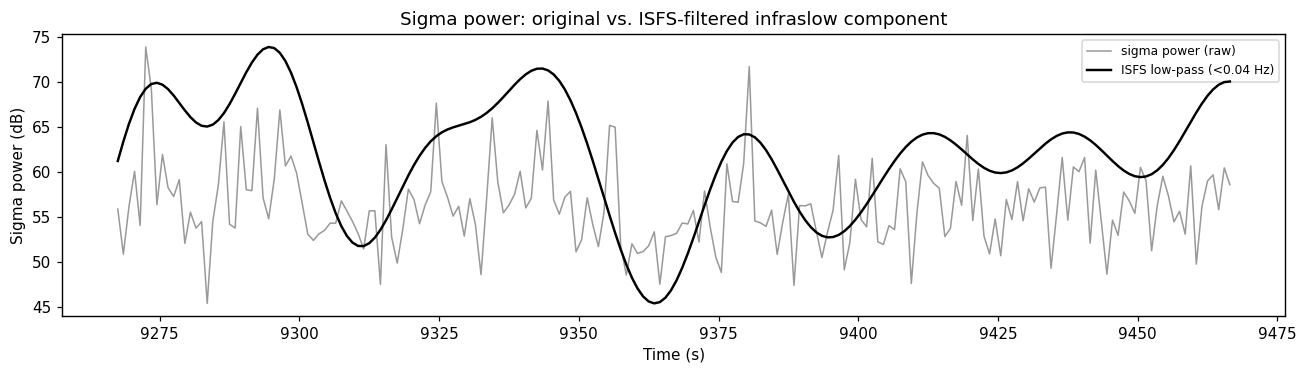

In [21]:
if HAS_N2_BOUTS:
    fig, ax = plt.subplots(figsize=(12, 3.5))
    me = (t_env >= win_start) & (t_env <= win_end)
    ax.plot(t_env[me], sigma_db[me], color="0.6", lw=1.0, label="sigma power (raw)")
    ax2 = ax.twinx()
    ax2.plot(t_env[me], isfs_filtered[me], color="k", lw=1.6, label="ISFS low-pass (<0.04 Hz)")
    ax2.set_yticks([])
    ax.set(xlabel="Time (s)", ylabel="Sigma power (dB)",
           title="Sigma power: original vs. ISFS-filtered infraslow component")
    l1, la1 = ax.get_legend_handles_labels()
    l2, la2 = ax2.get_legend_handles_labels()
    ax.legend(l1 + l2, la1 + la2, loc="upper right", fontsize=8)
    fig.tight_layout()

### Standardization

Each N2 bout is standardized (z-scored) **using its own mean and SD**.

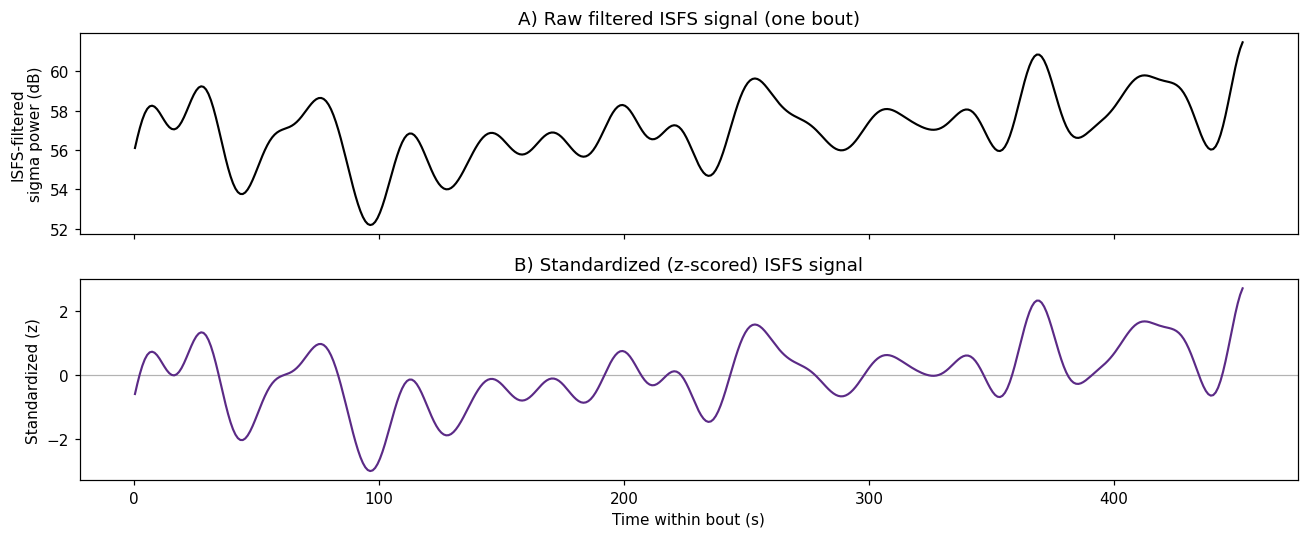

In [22]:
if HAS_N2_BOUTS:
    bouts_for_phase = n2_bouts_with_spindles if HAS_SPINDLE_BOUTS else n2_bouts
    PHASE_BOUT_IDX = 0
    a, b = bouts_for_phase[PHASE_BOUT_IDX]
    m0 = (t_env >= a) & (t_env < b)
    tt = t_env[m0] - a
    raw_bout = sigma_db[m0]
    filt_bout = isfs_filtered[m0]
    _std = filt_bout.std()
    isfs_z = (filt_bout - filt_bout.mean()) / _std if _std > 0 else filt_bout - filt_bout.mean()

    fig, (axA, axB) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axA.plot(tt, filt_bout, color="k", lw=1.4)
    axA.set(ylabel="ISFS-filtered\nsigma power (dB)", title="A) Raw filtered ISFS signal (one bout)")
    axB.axhline(0, color="0.7", lw=0.8)
    axB.plot(tt, isfs_z, color=PURPLE, lw=1.4)
    axB.set(xlabel="Time within bout (s)", ylabel="Standardized (z)",
            title="B) Standardized (z-scored) ISFS signal")
    fig.tight_layout()

## 14. ISFS Phase

```
Filtered ISFS signal (isfs_z)
       |
       v
Zero-crossing / peak / trough landmark scan (isfs_phase_bins)
       |
       v
Instantaneous phase, -pi to +pi (continuous_phase_samples)
```

**Phase convention**:

| Phase (rad)     | Meaning                                          |
|-----------------|---------------------------------------------------|
| `0`             | ascending (rising) zero-crossing -- mean sigma power, increasing |
| `+pi/2`         | sigma-power **peak** (maximum)                    |
| `+/-pi`         | descending (falling) zero-crossing -- mean sigma power, decreasing |
| `-pi/2`         | sigma-power **trough** (minimum)                  |

In [23]:
if HAS_N2_BOUTS:
    phase_bins, isfs_cycles = isfs_phase_bins(tt, isfs_z, isfs_period=ISFS_PERIOD_SEC)
    isfs_phase = continuous_phase_samples(tt, isfs_z, isfs_period=ISFS_PERIOD_SEC)

    valid_phase = isfs_phase[~np.isnan(isfs_phase)]
    if valid_phase.size:
        assert np.all((valid_phase >= -np.pi - 1e-6) & (valid_phase <= np.pi + 1e-6)), (
            "phase values must lie within [-pi, pi]"
        )

    print(f"{len(isfs_cycles)} valid ISFS cycle(s) found in this bout "
          f"({(phase_bins > 0).sum()}/{phase_bins.size} samples in a valid cycle)")

    if isfs_cycles:
        c = isfs_cycles[0]
        print("\nPhase convention check (first valid cycle in this bout):")
        for name, idx in [("start (descending zero-x)", c["start"]), ("trough", c["trough"]),
                           ("mid (ascending zero-x)", c["mid"]), ("peak", c["peak"]),
                           ("end (descending zero-x)", c["end"])]:
            print(f"  {name:28s}: phase = {isfs_phase[idx]:+.2f} rad, value = {isfs_z[idx]:+.2f} (z)")
    else:
        print("No complete ISFS cycle in this particular bout -- try a different PHASE_BOUT_IDX.")

5 valid ISFS cycle(s) found in this bout (240/453 samples in a valid cycle)

Phase convention check (first valid cycle in this bout):
  start (descending zero-x)   : phase = -3.14 rad, value = +0.06 (z)
  trough                      : phase = -1.57 rad, value = -2.02 (z)
  mid (ascending zero-x)      : phase = +0.00 rad, value = -0.02 (z)
  peak                        : phase = +1.57 rad, value = +0.97 (z)
  end (descending zero-x)     : phase = +3.14 rad, value = +0.22 (z)


### Figure: sigma power, filtered signal, standardization and phase (one bout)

Top: sigma power (grey) with spindles (blue dots) and the ISFS-filtered course
(black, right axis). 

Bottom: the standardized course with peaks/troughs/zero
crossings marked, and every valid cycle shaded and numbered by phase bin (1-4
negative half-wave, 5-8 positive half-wave; grey hatching = outside any valid
25-100 s cycle, "Not ISFS").

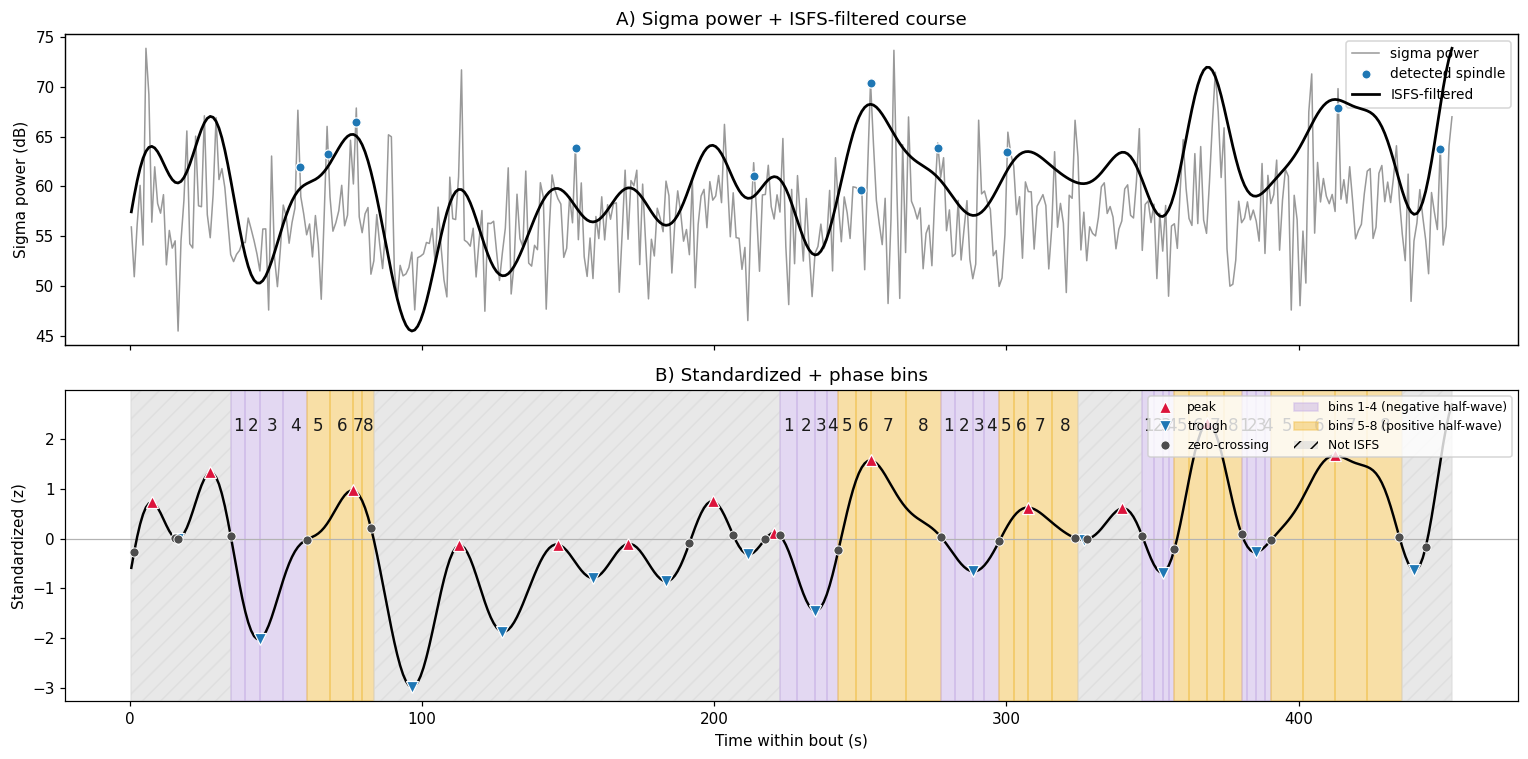

In [24]:
if HAS_N2_BOUTS:
    from scipy.signal import find_peaks

    fig, (axT, axB) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axT.plot(tt, raw_bout, color="0.6", lw=1.0, label="sigma power")
    pk_t = peak_times[(peak_times >= a) & (peak_times < b)]
    axT.plot(pk_t - a, env_at(pk_t), "o", color=BLUE, ms=6, mec="white", mew=0.8, zorder=5,
             label="detected spindle")
    axT2 = axT.twinx()
    axT2.plot(tt, filt_bout, color="k", lw=1.8, label="ISFS-filtered")
    axT2.set_yticks([])
    axT.set_ylabel("Sigma power (dB)")
    axT.set_title("A) Sigma power + ISFS-filtered course")
    l1, la1 = axT.get_legend_handles_labels()
    l2, la2 = axT2.get_legend_handles_labels()
    axT.legend(l1 + l2, la1 + la2, loc="upper right", fontsize=9, frameon=True)

    pk_i, _ = find_peaks(isfs_z)
    tr_i, _ = find_peaks(-isfs_z)
    zc_i = np.where(np.diff(np.signbit(isfs_z)))[0]

    axB.axhline(0, color="0.7", lw=0.8)
    axB.plot(tt, isfs_z, color="k", lw=1.6)
    axB.plot(tt[pk_i], isfs_z[pk_i], "^", color="crimson", ms=8, mec="white", mew=0.8, label="peak")
    axB.plot(tt[tr_i], isfs_z[tr_i], "v", color="tab:blue", ms=8, mec="white", mew=0.8, label="trough")
    axB.plot(tt[zc_i], isfs_z[zc_i], "o", color="0.3", ms=6, mec="white", mew=0.6, label="zero-crossing")

    run_edges = np.flatnonzero(np.diff(phase_bins) != 0)
    run_starts = np.concatenate([[0], run_edges + 1])
    run_ends = np.concatenate([run_edges + 1, [phase_bins.size]])
    y_top = axB.get_ylim()[1] if axB.get_ylim()[1] > 0 else 1.0
    for s_i, e_i in zip(run_starts, run_ends):
        label = int(phase_bins[s_i])
        x0, x1 = tt[s_i], tt[min(e_i, phase_bins.size - 1)]
        if label == 0:
            axB.axvspan(x0, x1, color="0.85", alpha=0.6, hatch="//", zorder=0)
            continue
        col = LPURPLE if label <= 4 else GOLD
        axB.axvspan(x0, x1, color=col, alpha=0.5, zorder=0)
        axB.text((x0 + x1) / 2, y_top * 0.82, str(label), ha="center", va="top", fontsize=11, color="0.1")

    axB.legend(handles=axB.get_legend_handles_labels()[0] + [
        Patch(color=LPURPLE, alpha=0.5, label="bins 1-4 (negative half-wave)"),
        Patch(color=GOLD, alpha=0.5, label="bins 5-8 (positive half-wave)"),
        Patch(facecolor="0.85", alpha=0.6, hatch="//", label="Not ISFS"),
    ], loc="upper right", fontsize=8, ncol=2, frameon=True)
    axB.set(xlabel="Time within bout (s)", ylabel="Standardized (z)", title="B) Standardized + phase bins")

    fig.tight_layout()

## 15. ISFS Phase Bins

`N_PHASE_BINS = 8`, each `pi/4` radians wide, centered via `bin_center_angle`.
Bins are **not** equal-width in time -- boundaries fall at the mean sample
index between landmarks (start/trough/mid/peak/end), so each bin's time-width
follows where the trough/peak actually falls within its half-wave.

In [25]:
bin_ids = np.arange(1, N_PHASE_BINS + 1)
bin_centers = bin_center_angle(bin_ids)
bin_edges = -np.pi + (np.pi / 4) * np.arange(N_PHASE_BINS + 1)

phase_bin_table = pd.DataFrame({
    "bin": bin_ids,
    "edge_start_rad": bin_edges[:-1],
    "edge_end_rad": bin_edges[1:],
    "center_rad": bin_centers,
    "half_wave": ["negative (trough side)" if b <= 4 else "positive (peak side)" for b in bin_ids],
})
phase_bin_table

,bin,edge_start_rad,edge_end_rad,center_rad,half_wave
0,1,-3.141593,-2.356194,-2.748894,negative (trough side)
1,2,-2.356194,-1.570796,-1.963495,negative (trough side)
2,3,-1.570796,-0.785398,-1.178097,negative (trough side)
3,4,-0.785398,0.000000,-0.392699,negative (trough side)
4,5,0.000000,0.785398,0.392699,positive (peak side)
5,6,0.785398,1.570796,1.178097,positive (peak side)
6,7,1.570796,2.356194,1.963495,positive (peak side)
7,8,2.356194,3.141593,2.748894,positive (peak side)


## 16. Spindle Distribution Across ISFS Phase

In [26]:
if HAS_N2_BOUTS and HAS_SPINDLE_BOUTS:
    bouts_data = []
    for a_b, b_b in n2_bouts_with_spindles:
        m0 = (t_env >= a_b) & (t_env < b_b)
        tt_b = t_env[m0] - a_b
        filt_b = isfs_filtered[m0]
        std = filt_b.std()
        std_b = (filt_b - filt_b.mean()) / std if std > 0 else filt_b - filt_b.mean()
        bins_b, _ = isfs_phase_bins(tt_b, std_b, isfs_period=ISFS_PERIOD_SEC)
        pk_b = peak_times[(peak_times >= a_b) & (peak_times < b_b)] - a_b
        bouts_data.append((tt_b, bins_b, pk_b))

    dist = isfs_event_phase_distribution(bouts_data, min_events=5)
else:
    dist = None
    print("Skipping spindle-phase distribution (no N2 bouts / no spindle-containing bouts).")

Spindle-rich phase bin: 6 (center phase +1.18 rad, peak side)


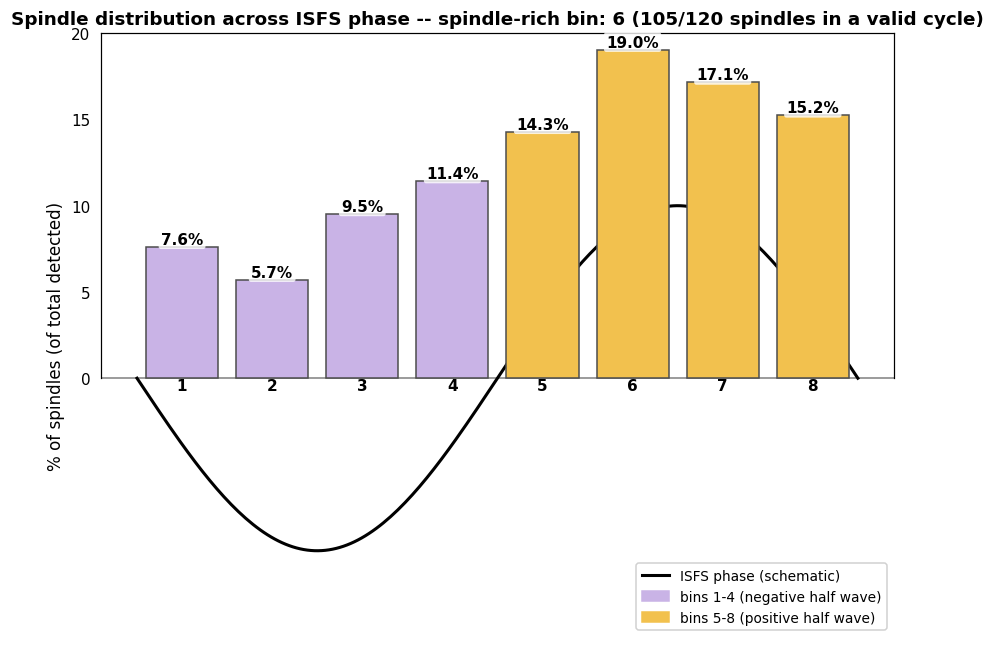

In [ ]:
if dist is None:
    if HAS_N2_BOUTS and HAS_SPINDLE_BOUTS:
        print("Fewer than 5 spindles total in spindle-containing N2 bouts -- "
              "excluded from the phase distribution (near-empty denominator).")
    preferred_bin = np.nan
else:
    preferred_bin = int(np.argmax(dist["pct"])) + 1

    label_bbox = dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = [LPURPLE if b <= 4 else GOLD for b in bin_ids]
    ax.bar(bin_ids, dist["pct"], color=colors, edgecolor="0.3", zorder=2)
    for b, pct in zip(bin_ids, dist["pct"]):
        ax.text(b, pct, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10,
                fontweight="bold", bbox=label_bbox, zorder=6)

    ax.set(xticks=list(bin_ids), xticklabels=[""] * (len(bin_ids)))
    ax.set_ylabel("% of spindles (of total detected)", fontsize=11)
    ax.set_title(f"Spindle distribution across ISFS phase -- spindle-rich bin: {preferred_bin} "
                 f"({dist['n_in_isfs']}/{dist['n_total']} spindles in a valid cycle)",
                 fontsize=12, fontweight="bold")
    ax.tick_params(labelsize=10)

    y0, y1 = ax.get_ylim()
    span = y1 - y0
    amp = 0.50 * span
    x_smooth = np.linspace(0.5, N_PHASE_BINS + 0.5, 200)
    y_smooth = -amp * np.sin(2 * np.pi * (x_smooth - 0.5) / N_PHASE_BINS)
    ax.plot(x_smooth, y_smooth, color="k", lw=2.0, ls="-", zorder=1,
            label="ISFS phase (schematic)")
    ax.axhline(0, color="0.5", lw=1.0, zorder=0)
    ax.set_ylim(min(y0, -amp - 0.03 * span), max(y1, amp + 0.03 * span))

    for b in bin_ids:
        ax.text(b, 0, str(b), ha="center", va="top", fontsize=10, fontweight="bold")

    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{t:g}" if t >= 0 else "" for t in yticks])
    ax.tick_params(axis="both", bottom=False, left=False)

    _, y1f = ax.get_ylim()
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_bounds(0, y1f)
    ax.spines["right"].set_bounds(0, y1f)

    ax.legend(handles=ax.get_legend_handles_labels()[0] + [
        Patch(color=LPURPLE, label="bins 1-4 (negative half wave)"),
        Patch(color=GOLD, label="bins 5-8 (positive half wave)"),
        ],
        loc="lower right", frameon=True, framealpha=0.9, fontsize=9)
    fig.tight_layout()

    print(f"Spindle-rich phase bin: {preferred_bin} "
          f"(center phase {bin_center_angle(preferred_bin):+.2f} rad, "
          f"{'trough side' if preferred_bin <= 4 else 'peak side'})")


## 17. Infraslow Phase vs. U-Sleep Sleep-Stage Probability

In [28]:
N_PHASE_POINTS = 8  # equal-width phase points spanning the continuous ISFS phase range

if HAS_N2_BOUTS:
    phase_ts = build_subject_continuous_phase_timeseries(t_env, isfs_filtered, n2_bouts, isfs_period=ISFS_PERIOD_SEC)
    in_cycle = ~np.isnan(phase_ts["phase_angle"])
    t_in = phase_ts["t"][in_cycle]
    phase_in = phase_ts["phase_angle"][in_cycle]
    probs_in = hypnodensity_probs_at_times(t_in, t_epoch, hypnodensity_3s)

    phase_edges = np.linspace(-np.pi, np.pi, N_PHASE_POINTS + 1)
    phase_points = (phase_edges[:-1] + phase_edges[1:]) / 2
    point_idx = np.digitize(phase_in, phase_edges[1:-1])  # 0 .. N_PHASE_POINTS-1

    mean_probs_per_point = np.full((N_PHASE_POINTS, len(USLEEP_STAGE_ORDER)), np.nan)
    for p in range(N_PHASE_POINTS):
        sel = point_idx == p
        if sel.any():
            mean_probs_per_point[p] = probs_in[sel].mean(axis=0)

    n_complete_points = int(np.isfinite(mean_probs_per_point).all(axis=1).sum())
    print(f"{in_cycle.sum()}/{in_cycle.size} N2-bout envelope samples fell inside a valid ISFS cycle")
    print(f"{n_complete_points}/{N_PHASE_POINTS} phase points have samples in every stage")
else:
    print("No N2 bouts -- skipping the phase-vs-stage-probability analysis.")

3290/4293 N2-bout envelope samples fell inside a valid ISFS cycle
8/8 phase points have samples in every stage


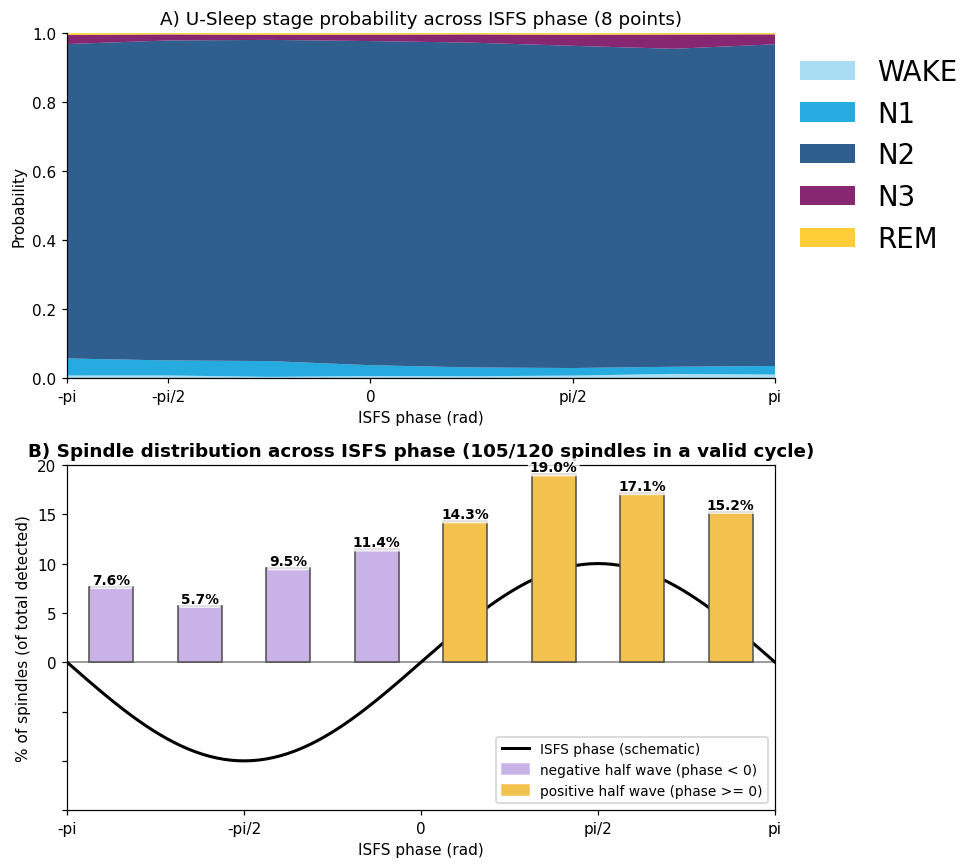

In [29]:
if HAS_N2_BOUTS:
    stage_cols = [s.upper() for s in USLEEP_STAGE_ORDER]  # yasa's canonical 5-stage labels
    proba_arr = mean_probs_per_point
    n_missing = int(np.isnan(proba_arr).any(axis=1).sum())
    if n_missing:
        print(f"WARNING: {n_missing}/{N_PHASE_POINTS} phase point(s) have no in-cycle samples; "
              "filling by circular linear interpolation before plotting.")
        wrapped = np.vstack([proba_arr[-5:], proba_arr, proba_arr[:5]])
        wrapped = pd.DataFrame(wrapped).interpolate(limit_direction="both").to_numpy()
        proba_arr = wrapped[5 : 5 + N_PHASE_POINTS]
        proba_arr = proba_arr / proba_arr.sum(axis=1, keepdims=True)

    group_labels = [stage_cols[i] for i in np.argmax(proba_arr, axis=1)]
    proba_df = pd.DataFrame(proba_arr, columns=stage_cols)

    hyp_phase = yasa.Hypnogram(group_labels, n_stages=5, freq="1s", proba=proba_df)

    fig, (axT, axB) = plt.subplots(2, 1, figsize=(9, 8))
    hyp_phase.plot_hypnodensity(ax=axT)

    x_all = hyp_phase.timedelta.total_seconds() / 60
    if hyp_phase.duration > 90:
        x_all = x_all / 60
    tick_phases = np.array([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
    tick_idx = np.array([np.argmin(np.abs(phase_points - p)) for p in tick_phases])
    axT.set_xticks(x_all[tick_idx])
    axT.set_xticklabels(["-pi", "-pi/2", "0", "pi/2", "pi"])
    axT.set_xlabel("ISFS phase (rad)")
    axT.set_title(f"A) U-Sleep stage probability across ISFS phase ({N_PHASE_POINTS} points)")

    # --- B) spindle distribution across ISFS phase
    if dist is not None:
        label_bbox = dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
        bar_width = (2 * np.pi / N_PHASE_BINS) * 0.5
        bar_colors = [LPURPLE if c < 0 else GOLD for c in bin_centers]
        axB.bar(bin_centers, dist["pct"], width=bar_width, color=bar_colors, edgecolor="0.3", zorder=2)
        for c, pct in zip(bin_centers, dist["pct"]):
            axB.text(c, pct, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9,
                      fontweight="bold", bbox=label_bbox, zorder=6)

        y0, y1 = axB.get_ylim()
        span = y1 - y0
        amp = 0.50 * span
        x_smooth = np.linspace(-np.pi, np.pi, 200)
        y_smooth = amp * np.sin(x_smooth)
        axB.plot(x_smooth, y_smooth, color="k", lw=2.0, ls="-", zorder=1, label="ISFS phase (schematic)")
        axB.axhline(0, color="0.5", lw=1.0, zorder=0)
        axB.set_ylim(min(y0, -amp - 0.03 * span), max(y1, amp + 0.03 * span))

        axB.set(xlim=(-np.pi, np.pi),
                xticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
                xticklabels=["-pi", "-pi/2", "0", "pi/2", "pi"],
                xlabel="ISFS phase (rad)", ylabel="% of spindles (of total detected)")
        axB.set_title(f"B) Spindle distribution across ISFS phase "
                       f"({dist['n_in_isfs']}/{dist['n_total']} spindles in a valid cycle)",
                       fontsize=12, fontweight="bold")
        axB.tick_params(labelsize=10)

        yticks = axB.get_yticks()
        axB.set_yticks(yticks)
        axB.set_yticklabels([f"{t:g}" if t >= 0 else "" for t in yticks])

        axB.legend(handles=axB.get_legend_handles_labels()[0] + [
            Patch(color=LPURPLE, label="negative half wave (phase < 0)"),
            Patch(color=GOLD, label="positive half wave (phase >= 0)")],
            loc="lower right", frameon=True, framealpha=0.9, fontsize=9)
    else:
        axB.text(0.5, 0.5, "No spindle-phase distribution available\n(fewer than 5 spindles)",
                  ha="center", va="center", transform=axB.transAxes)
        axB.set_title("B) Spindle distribution across ISFS phase", fontsize=12, fontweight="bold")
        axB.set_xlim(-np.pi, np.pi)
        axB.set_xticks([])
        axB.set_yticks([])

    fig.tight_layout()

## 18. Final Feature Summary

In [30]:
summary = {
    "channel": CHANNEL,
    "recording_duration_min": eeg_duration_sec / 60.0,
    "n2_total_duration_min": n2_bout_total_sec / 60.0 if n2_bouts.size else 0.0,
    "n_n2_bouts": int(len(n2_bouts)),
    "n_spindles_total": int(n_spindles),
    "n2_spindle_rate_per_min": n2_bout_spindle_rate,
    "mean_spindle_duration_sec": mean_spindle_duration_sec,
    "mean_spindle_amplitude_uv": mean_spindle_amplitude_uv,
    "mean_spindle_frequency_hz": mean_spindle_frequency_hz,
    "mean_spindle_power_log10uv2": mean_spindle_power,
    "isfs_detected": bool(detected) if FIT_OK else False,
    "isfs_peak_freq_hz": isfs_peak_freq,
    "isfs_peak_period_sec": isfs_peak_period_sec,
    "isfs_amplitude": amp if FIT_OK else np.nan,
    "isfs_bandwidth_hz": bandwidth if FIT_OK else np.nan,
    "isfs_auc": auc if FIT_OK else np.nan,
    "isfs_chromatogram_peak_area": isfs_chromatogram_area if FIT_OK else np.nan,
    "preferred_spindle_phase_bin": preferred_bin,
}
summary_df = pd.DataFrame([summary])
summary_df.T.rename(columns={0: "value"})

,value
channel,C3
recording_duration_min,460.766667
n2_total_duration_min,71.55
n_n2_bouts,11
n_spindles_total,239
n2_spindle_rate_per_min,1.677149
mean_spindle_duration_sec,0.743933
mean_spindle_amplitude_uv,51.695083
mean_spindle_frequency_hz,12.872424
mean_spindle_power_log10uv2,1.997388
